# Sales Analysis & Prediction
Analyzing retail sales data to uncover business insights and predict future sales using a Random Forest model.  
**Dataset:** Superstore Sales Dataset  
**Model:** Random Forest Regressor  
**MAE:** $215.99 | **R2:** 0.21

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

## Data Cleaning & Feature Engineering

In [7]:
df = df.drop(columns=['Row ID', 'Customer ID', 'Product ID','Customer Name', 'Product Name', 'Country'])
print(df.shape)

(9994, 15)


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date', 'Order Month', 'Order Year', 'Shipping Days']])

     Order Date  Ship Date  Order Month  Order Year  Shipping Days
0    2016-11-08 2016-11-11           11        2016              3
1    2016-11-08 2016-11-11           11        2016              3
2    2016-06-12 2016-06-16            6        2016              4
3    2015-10-11 2015-10-18           10        2015              7
4    2015-10-11 2015-10-18           10        2015              7
...         ...        ...          ...         ...            ...
9989 2014-01-21 2014-01-23            1        2014              2
9990 2017-02-26 2017-03-03            2        2017              5
9991 2017-02-26 2017-03-03            2        2017              5
9992 2017-02-26 2017-03-03            2        2017              5
9993 2017-05-04 2017-05-09            5        2017              5

[9994 rows x 5 columns]


In [9]:
df = df.drop(columns=['Order Date', 'Ship Date'])

## EDA

In [10]:
region = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(region)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


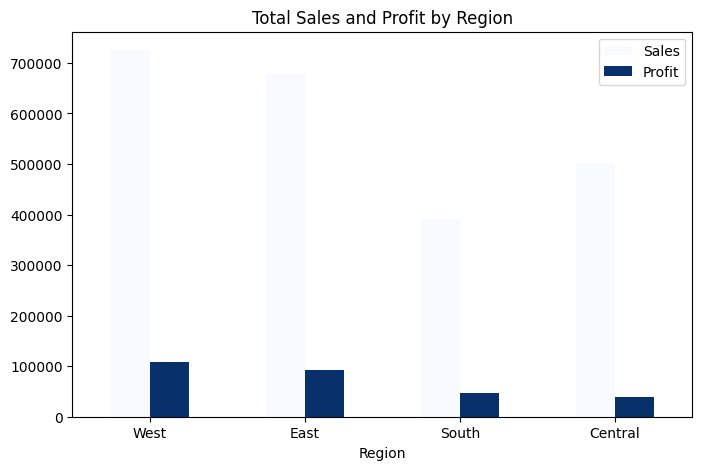

In [36]:
region[['Sales', 'Profit']].plot(kind='bar', figsize=(8,5), colormap='Blues')
plt.title('Total Sales and Profit by Region')
plt.xticks(rotation=0)
plt.show()

In [12]:
category = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(category)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Office Supplies  719047.0320  122490.8008
Furniture        741999.7953   18451.2728


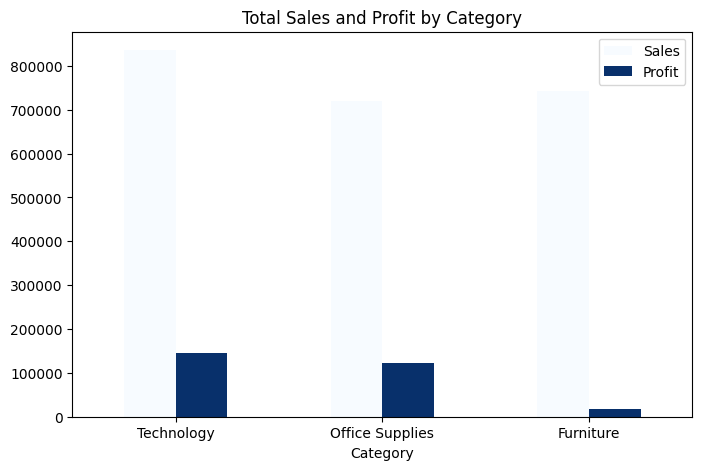

In [35]:
category[['Sales', 'Profit']].plot(kind='bar', figsize=(8,5), colormap='Blues')
plt.title('Total Sales and Profit by Category')
plt.xticks(rotation=0)
plt.show()

### Identifying Loss-Making Products

In [37]:
subcategory = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=True)
print(subcategory)

                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995
Fasteners       3024.2800    949.5182
Machines      189238.6310   3384.7569
Labels         12486.3120   5546.2540
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Furnishings    91705.1640  13059.1436
Appliances    107532.1610  18138.0054
Storage       223843.6080  21278.8264
Chairs        328449.1030  26590.1663
Binders       203412.7330  30221.7633
Paper          78479.2060  34053.5693
Accessories   167380.3180  41936.6357
Phones        330007.0540  44515.7306
Copiers       149528.0300  55617.8249


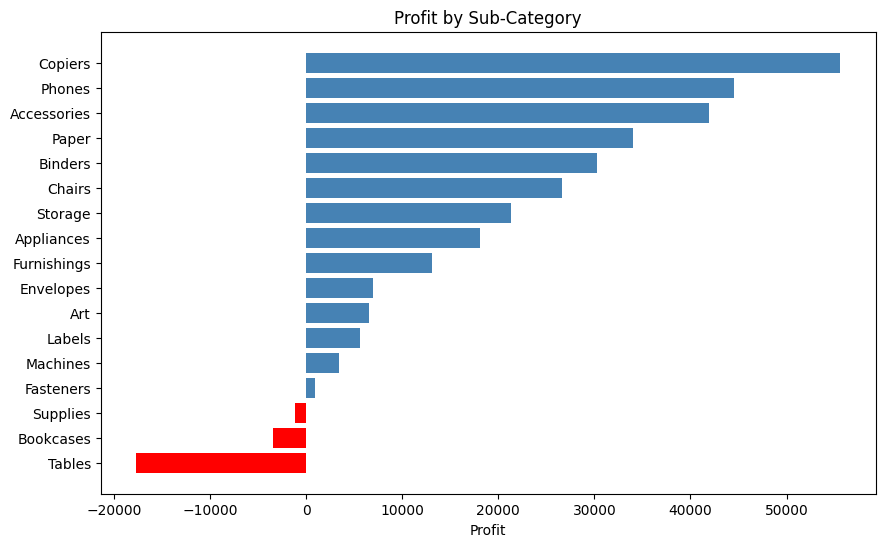

In [39]:
plt.figure(figsize=(10,6))
colors = ['red' if x < 0 else 'steelblue' for x in subcategory['Profit']]
plt.barh(subcategory.index, subcategory['Profit'], color=colors)
plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.show()

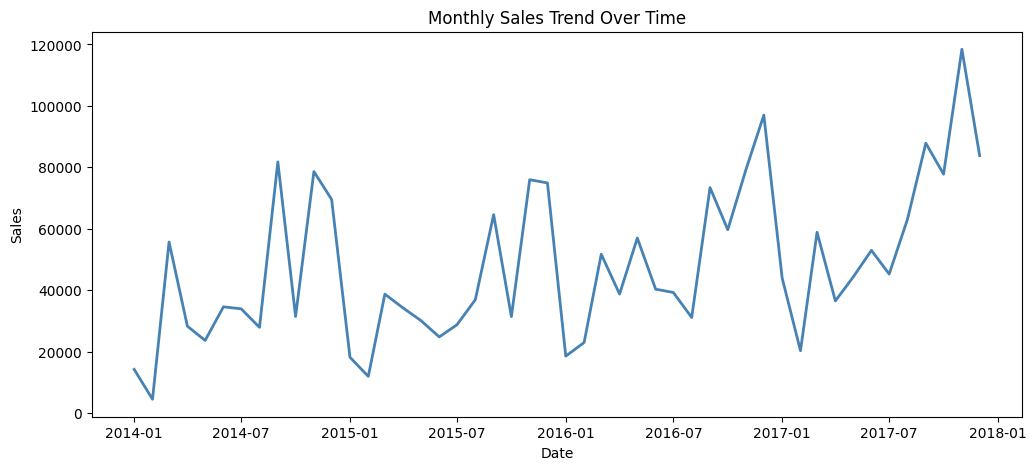

In [16]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(dict(year=monthly_sales['Order Year'],month=monthly_sales['Order Month'], day=1))

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

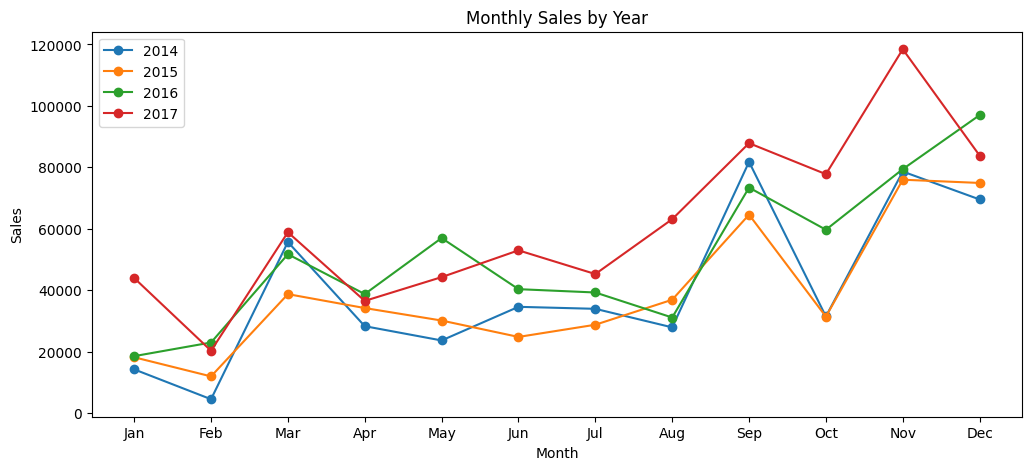

In [17]:
plt.figure(figsize=(12,5))
for year in monthly_sales['Order Year'].unique():
    yearly = monthly_sales[monthly_sales['Order Year'] == year]
    plt.plot(yearly['Order Month'], yearly['Sales'], marker='o', label=str(year))

plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

### Discount Impact on Profit

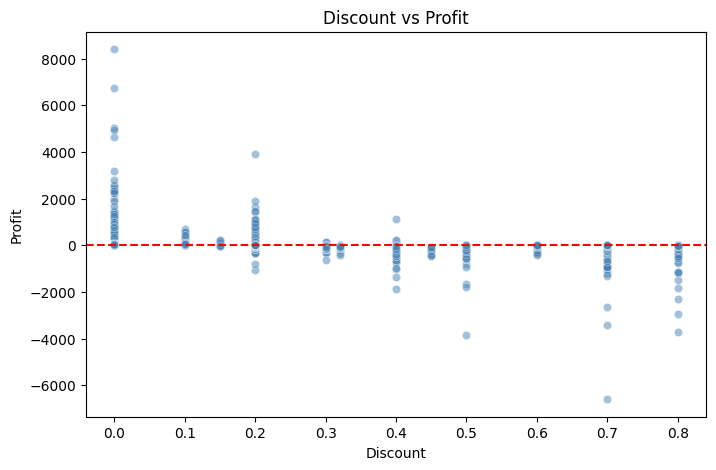

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.show()

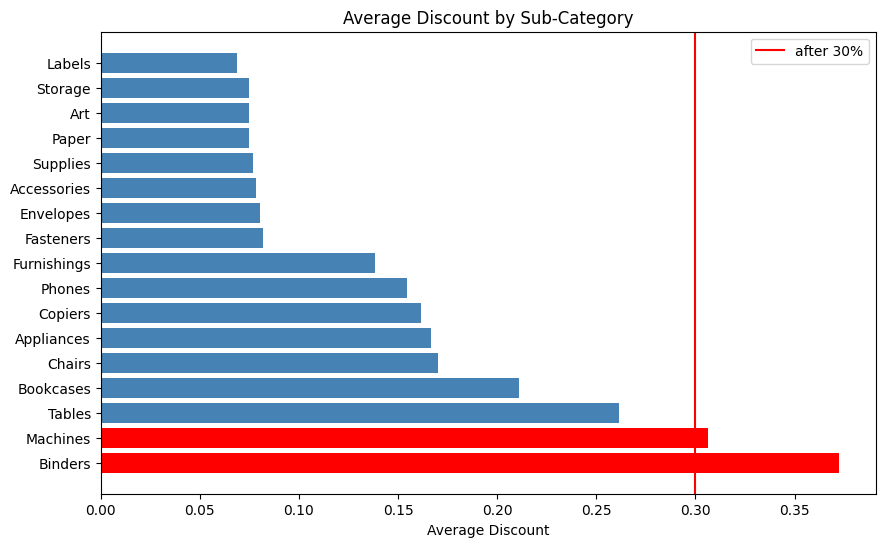

In [19]:
discount = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
colors = ['red' if x > 0.3 else 'steelblue' for x in discount.values]
plt.barh(discount.index, discount.values, color=colors)
plt.axvline(x=0.3, color='red', label='after 30%')
plt.title('Average Discount by Sub-Category')
plt.xlabel('Average Discount')
plt.legend()
plt.show()

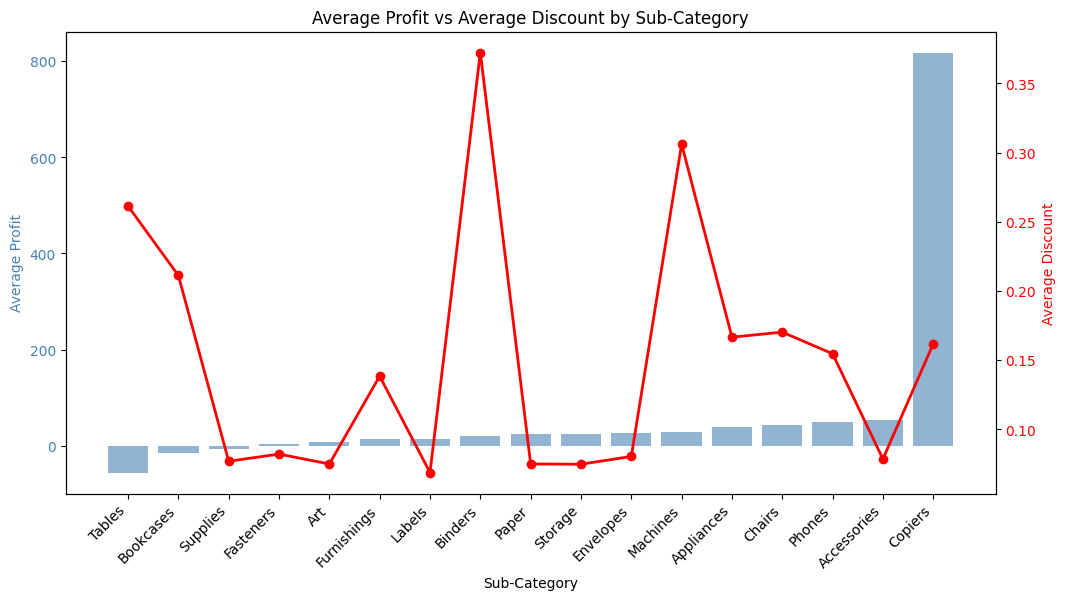

In [20]:
discount_profit = df.groupby('Sub-Category')[['Discount', 'Profit']].mean().sort_values('Profit')

fig, ax1 = plt.subplots(figsize=(12,6))

color = 'steelblue'
ax1.set_xlabel('Sub-Category')
ax1.set_ylabel('Average Profit', color=color)
ax1.bar(discount_profit.index, discount_profit['Profit'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'red'
ax2.set_ylabel('Average Discount', color=color)
ax2.plot(discount_profit.index, discount_profit['Discount'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Average Profit vs Average Discount by Sub-Category')
plt.show()

## Preprocessing

In [21]:
df.dtypes

Order ID          object
Ship Mode         object
Segment           object
City              object
State             object
Postal Code        int64
Region            object
Category          object
Sub-Category      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Order Month        int32
Order Year         int32
Shipping Days      int64
dtype: object

In [22]:
df = df.drop(columns=['Order ID', 'City', 'State', 'Postal Code'])
df_model = pd.get_dummies(df, columns=['Ship Mode', 'Segment', 'Region','Category', 'Sub-Category'])
df_model.dtypes

Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Order Month                   int32
Order Year                    int32
Shipping Days                 int64
Ship Mode_First Class          bool
Ship Mode_Same Day             bool
Ship Mode_Second Class         bool
Ship Mode_Standard Class       bool
Segment_Consumer               bool
Segment_Corporate              bool
Segment_Home Office            bool
Region_Central                 bool
Region_East                    bool
Region_South                   bool
Region_West                    bool
Category_Furniture             bool
Category_Office Supplies       bool
Category_Technology            bool
Sub-Category_Accessories       bool
Sub-Category_Appliances        bool
Sub-Category_Art               bool
Sub-Category_Binders           bool
Sub-Category_Bookcases         bool
Sub-Category_Chairs            bool
Sub-Category_Copiers        

In [23]:
df_model.dtypes.unique()

array([dtype('float64'), dtype('int64'), dtype('int32'), dtype('bool')],
      dtype=object)

## Model Building

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
X = df_model.drop(columns=['Sales'])
y = df_model['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
print(f"Training size: {X_train.shape}")
print(f"Testing size: {X_test.shape}")

Training size: (7995, 37)
Testing size: (1999, 37)


In [27]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = rf.predict(X_test)

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [30]:
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"R2:   {r2:.2f}")

MAE:  83.95
MSE:  242033.14
R2:   0.59


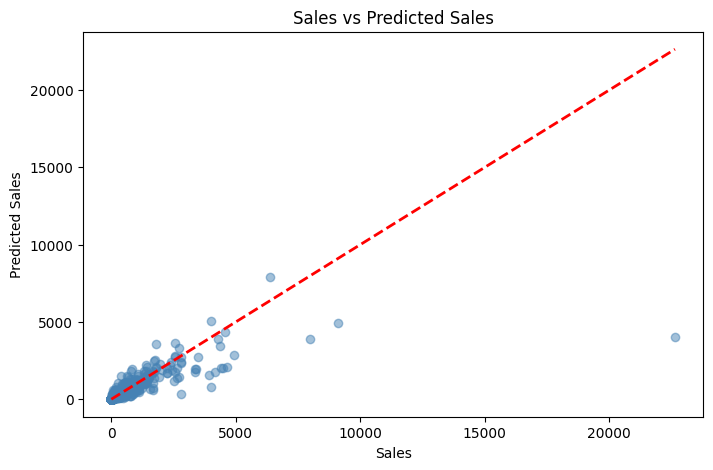

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Sales vs Predicted Sales')
plt.xlabel('Sales')
plt.ylabel('Predicted Sales')
plt.show()

## Feature Importance

C:\Users\Ahmad\AppData\Local\Temp\ipykernel_14972\3993963859.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')


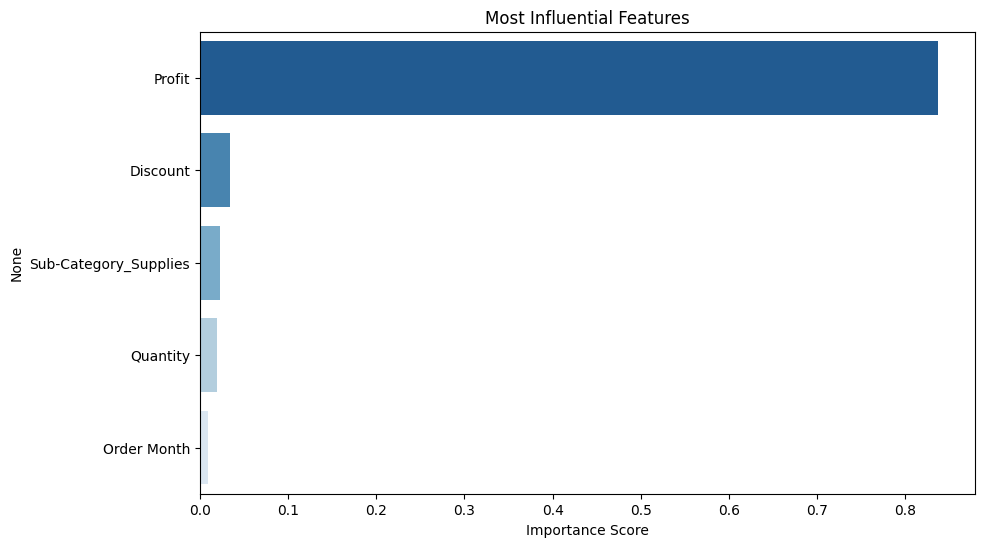

In [32]:
feature_names = df_model.drop(columns=['Sales']).columns
importance = pd.Series(rf.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)[:5]
plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')
plt.title('Most Influential Features')
plt.xlabel('Importance Score')
plt.show()

Note: After reviewing feature importances, I noticed Profit was included as a feature. Since Profit is directly derived from Sales, this causes data leakage and inflates model performance. Re-running the model without it.

In [33]:
X = df_model.drop(columns=['Sales', 'Profit'])
y = df_model['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"R2:   {r2:.2f}")

MAE:  215.99
MSE:  467139.96
R2:   0.21


C:\Users\Ahmad\AppData\Local\Temp\ipykernel_14972\166860844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')


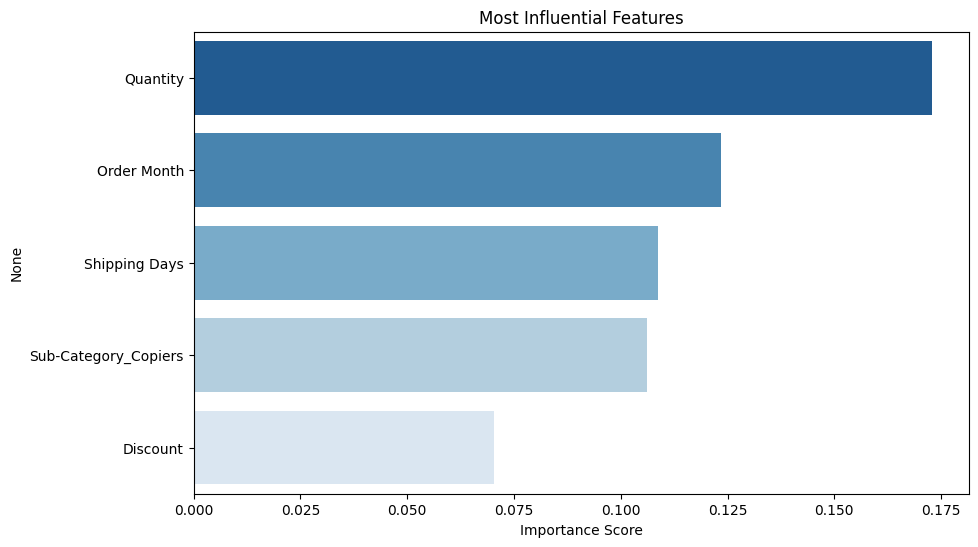

In [34]:
feature_names = df_model.drop(columns=['Sales', 'Profit']).columns
importance = pd.Series(rf.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)[:5]
plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')
plt.title('Most Influential Features')
plt.xlabel('Importance Score')
plt.show()